In [7]:
# prompt: 請顯示内建iris資料，并存成dataframe，再呈現前五筆資料

from sklearn import datasets  #此函式中有内建資料集
import pandas as pd

# 載入 iris 資料集
iris = datasets.load_iris()
print(type(iris)) #檢查其使用的資料集1

# 將資料轉換成 pandas DataFrame
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
iris_df['target'] = iris.target
print(type(iris_df)) #檢查其使用的資料集2
# 顯示前五筆資料（以表格呈現）
iris_df.head()


<class 'sklearn.utils._bunch.Bunch'>
<class 'pandas.core.frame.DataFrame'>


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [9]:
# prompt: 顯示iris_df之敘述統計（各統計指標之整理和呈現）（測量樣本和有關的內容提供簡單的總結）

iris_df.describe()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [13]:
# prompt: 請針對iris_df進行決策樹分類建模，特徵變數：
# sepal length (cm)	sepal width (cm)	petal length (cm)	petal width (cm)，目標變數：target，顯示該模型之參數並進行初始化（先不用進行訓練，但先設定目標變數和特徵變數）

from sklearn.tree import DecisionTreeClassifier

# 初始化決策樹分類器
dt_classifier = DecisionTreeClassifier() #建立空模型

# 設定特徵變數和目標變數
features = ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
target = 'target'

# 顯示模型參數（呈現形式要注意，這樣較爲可視化）
dt_classifier.get_params()


{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': None,
 'splitter': 'best'}

In [18]:
# prompt: 以訓練資料及測試資料比率為7：3，樹的深度設定爲5，訓練及評估決策樹模型

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 分割訓練和測試資料集
X_train, X_test, y_train, y_test = train_test_split(iris_df[features], iris_df[target], test_size=0.3, random_state=42)

# 初始化決策樹分類器，並設定樹的深度
dt_classifier = DecisionTreeClassifier(max_depth=5,random_state=0) #設定隨機種子（雜訊）

# 訓練模型
dt_classifier.fit(X_train, y_train)

# 預測測試資料集
y_pred = dt_classifier.predict(X_test)

# 評估模型準確度
accuracy = accuracy_score(y_test, y_pred) #顯示評估指標
print(f"Accuracy: {accuracy}")


Accuracy: 1.0


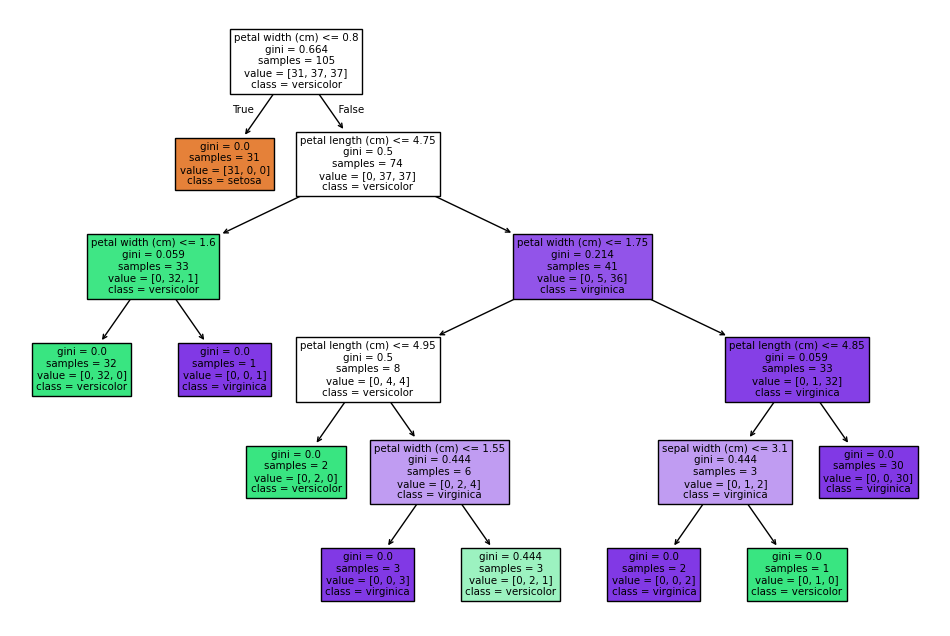

Accuracy: 1.0


In [19]:
# prompt: 請顯示決策樹的圖形，

from sklearn import datasets  #此函式中有内建資料集
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# 載入 iris 資料集
iris = datasets.load_iris()

# 將資料轉換成 pandas DataFrame
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
iris_df['target'] = iris.target

# 設定特徵變數和目標變數
features = ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
target = 'target'

# 分割訓練和測試資料集
X_train, X_test, y_train, y_test = train_test_split(iris_df[features], iris_df[target], test_size=0.3, random_state=42)

# 初始化決策樹分類器，並設定樹的深度
dt_classifier = DecisionTreeClassifier(max_depth=5,random_state=0) #設定隨機種子（雜訊）

# 訓練模型
dt_classifier.fit(X_train, y_train)

# 繪製決策樹
plt.figure(figsize=(12, 8))
plot_tree(dt_classifier, feature_names=features, class_names=iris.target_names, filled=True)
plt.show()

# 預測測試資料集
y_pred = dt_classifier.predict(X_test)

# 評估模型準確度
accuracy = accuracy_score(y_test, y_pred) #顯示評估指標
print(f"Accuracy: {accuracy}")


             Feature  Importance
3   petal width (cm)    0.568181
2  petal length (cm)    0.412336
1   sepal width (cm)    0.019482
0  sepal length (cm)    0.000000


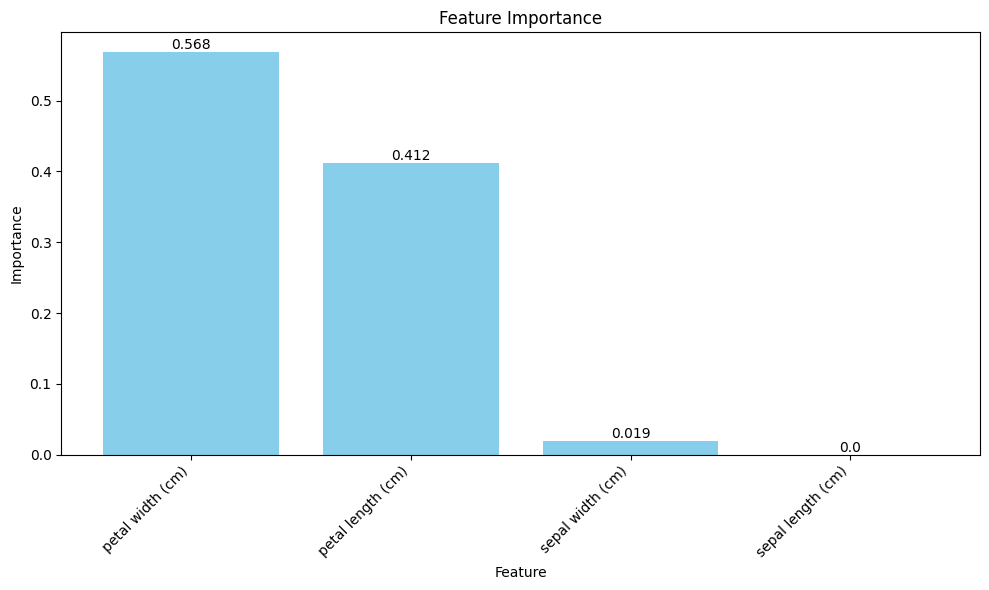

In [27]:
# prompt: 進行特徵重要性分析并且顯示特徵重要性及做成直方圖（顯示每一個直方圖的數值），再加上建立重要性dataframe，根據重要性進行排序,僅顯示此動作的程式即可，

import pandas as pd
import matplotlib.pyplot as plt

# Assuming dt_classifier is your trained DecisionTreeClassifier model
# and features is the list of feature names

feature_importances = dt_classifier.feature_importances_

# Create a DataFrame for feature importances
importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Display feature importances
print(importance_df)

# Create a bar plot of feature importances
plt.figure(figsize=(10, 6))
plt.bar(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Feature Importance")
plt.xticks(rotation=45, ha='right')

# Add value labels on top of the bars
for index, value in enumerate(importance_df['Importance']):
    plt.text(index, value, str(round(value, 3)), ha='center', va='bottom')

plt.tight_layout()
plt.show()
